In [18]:
# %pip install pandas matplotlib seaborn
# %pip install notebook
# %pip install seaborn
# %pip install scikit-learn
# %pip install pandas

### Carregando Dados

In [19]:
import sklearn as sklearn
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D



# Carregar os dados dos sensores
df1 = pd.read_csv('../../sensor_data GY-87_1.txt', sep=',', header=None, names=['X', 'Y', 'Z'], encoding='utf-8')
df2 = pd.read_csv('../../sensor_data GY-87_2.txt', sep=',', header=None, names=['X', 'Y', 'Z'], encoding='utf-8')
df3 = pd.read_csv('../../sensor_data GY-87_3.txt', sep=',', header=None, names=['X', 'Y', 'Z'], encoding='utf-8')

# Removendo os primeiros 10 mil valores de cada DataFrame
df1 = df1.iloc[10000:]
df2 = df2.iloc[10000:]
df3 = df3.iloc[10000:]
tamanho_populacao = 990000 

# Resetando os índices dos DataFrames após a remoção
df1.reset_index(drop=True, inplace=True)
df2.reset_index(drop=True, inplace=True)
df3.reset_index(drop=True, inplace=True)

# Reduzir a apenas dois eixos, X e Z
df1 = df1[['X', 'Z']]
df2 = df2[['X', 'Z']]
df3 = df3[['X', 'Z']]

# Mostrar as primeiras linhas dos dados reduzidos
print(df1.head())
print(df2.head())
print(df3.head())

          X         Z
0 -0.006718  1.453533
1 -0.006710  1.453505
2 -0.006701  1.453476
3 -0.006697  1.453448
4 -0.006690  1.453421
          X         Z
0 -0.000913  1.077109
1 -0.000907  1.077128
2 -0.000900  1.077137
3 -0.000899  1.077138
4 -0.000900  1.077134
          X         Z
0  0.006742  1.121710
1  0.006752  1.121664
2  0.006753  1.121619
3  0.006757  1.121573
4  0.006760  1.121528


### A escolha do método que melhor se adapta ao caso de uso: A normalização Min-Max é útil quando você precisa de valores em uma escala positiva e limitada, enquanto a normalização Z-score é útil para quando você está lidando com dados que precisam ser padronizados em torno de uma média.
### Com base nesse quesito, a escolha que melhor se adapta é o Z-score.

In [20]:
from sklearn.preprocessing import StandardScaler
# Criar um objeto scaler
scaler = StandardScaler()

# Normalizar os dados de cada sensor
df1[['X', 'Z']] = scaler.fit_transform(df1[['X', 'Z']])
df2[['X', 'Z']] = scaler.fit_transform(df2[['X', 'Z']])
df3[['X', 'Z']] = scaler.fit_transform(df3[['X', 'Z']])

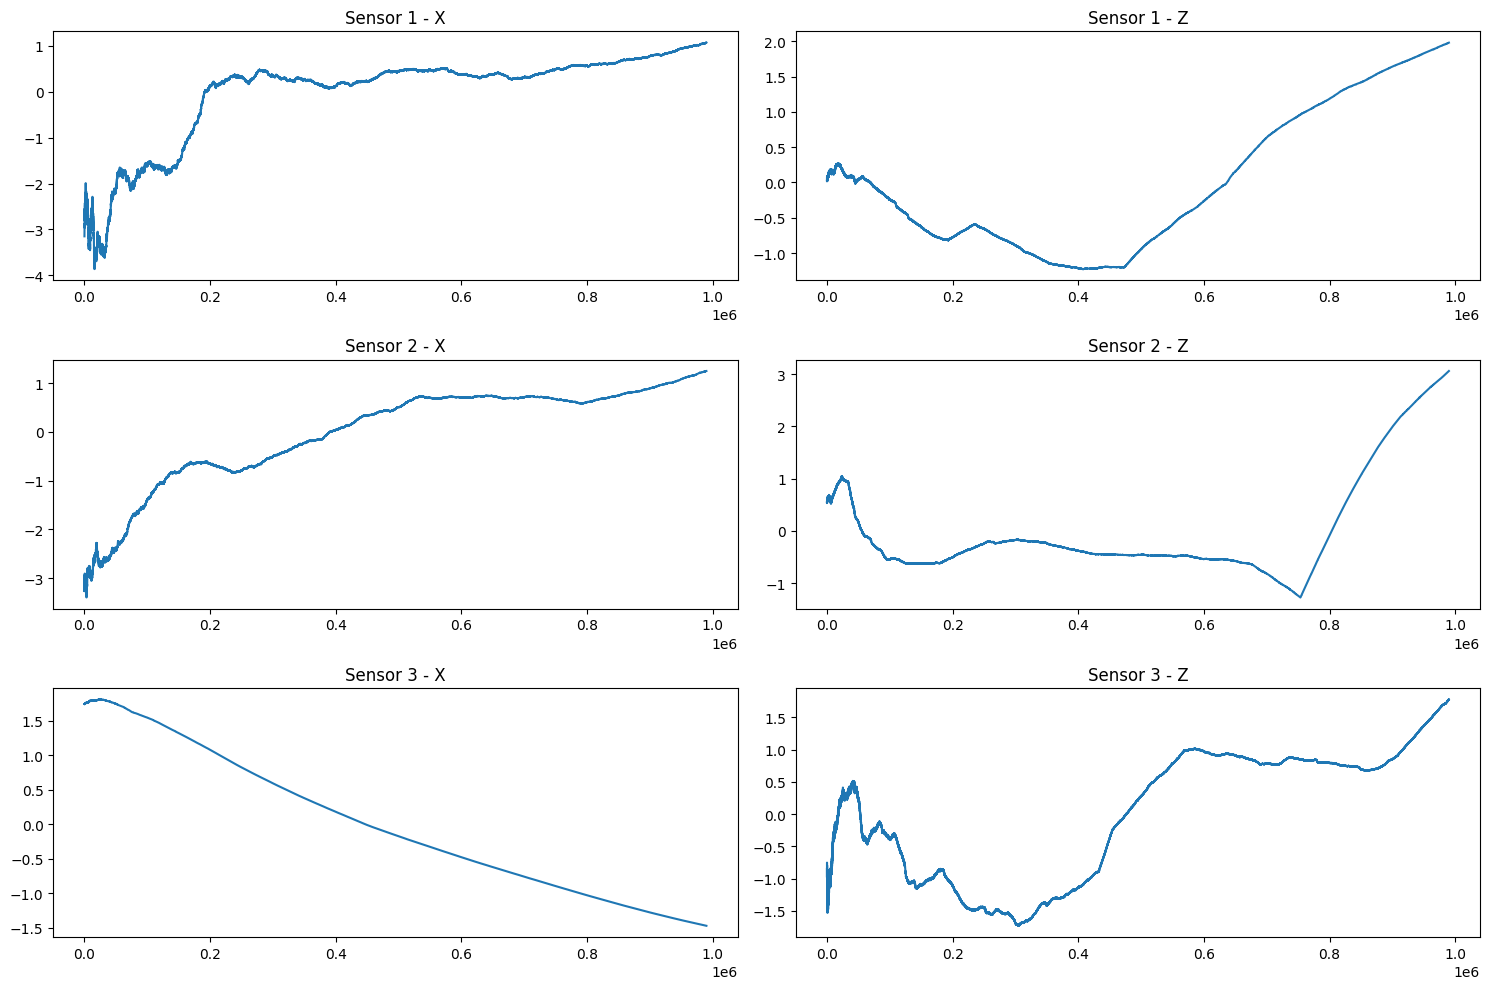

In [21]:
# Configuração do layout dos gráficos
fig, axs = plt.subplots(3, 2, figsize=(15, 10))  # 3 linhas, 3 colunas

# Sensor 1
axs[0, 0].plot(df1['X'])
axs[0, 0].set_title('Sensor 1 - X')
axs[0, 1].plot(df1['Z'])
axs[0, 1].set_title('Sensor 1 - Z')

# Sensor 2
axs[1, 0].plot(df2['X'])
axs[1, 0].set_title('Sensor 2 - X')
axs[1, 1].plot(df2['Z'])
axs[1, 1].set_title('Sensor 2 - Z')

# Sensor 3
axs[2, 0].plot(df3['X'])
axs[2, 0].set_title('Sensor 3 - X')
axs[2, 1].plot(df3['Z'])
axs[2, 1].set_title('Sensor 3 - Z')

# Ajustar layout
plt.tight_layout()
plt.show()

### Teste de linearidade

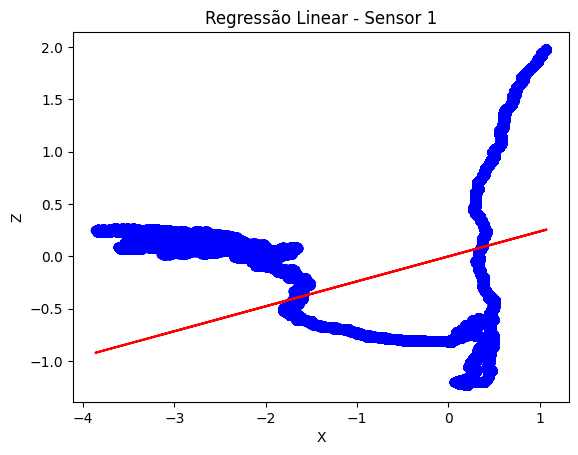

Coeficiente R² para Sensor 1: 0.056697576886187595


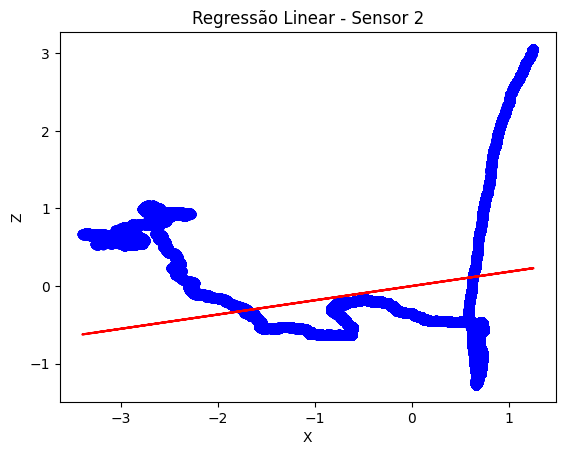

Coeficiente R² para Sensor 2: 0.033860319501174296


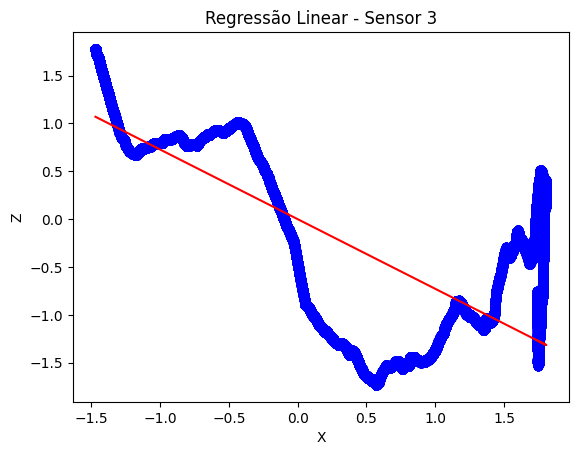

Coeficiente R² para Sensor 3: 0.5306705734381818


In [22]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Função para realizar o teste de regressão linear e plotar os resultados
def testar_regressao_linear(df, sensor_name):
    model = LinearRegression()
    X = df[['X']].values
    Z = df['Z'].values
    model.fit(X, Z)
    Z_pred = model.predict(X)
    r2_score = model.score(X, Z)

    plt.scatter(X, Z, color='blue')
    plt.plot(X, Z_pred, color='red')
    plt.title(f'Regressão Linear - {sensor_name}')
    plt.xlabel('X')
    plt.ylabel('Z')
    plt.show()
    
    print(f"Coeficiente R² para {sensor_name}: {r2_score}")

# Testando para cada sensor
testar_regressao_linear(df1, "Sensor 1")
testar_regressao_linear(df2, "Sensor 2")
testar_regressao_linear(df3, "Sensor 3")



### Seleção Sistemática de Amostra

In [23]:
import numpy as np
import pandas as pd

# Função para realizar a amostragem sistemática
def amostra_sistematica(dataframe, tamanho_amostra):
    # Considere uma população com N elementos, N = kn e k é um número inteiro
    tamanho_populacao = len(dataframe)
    k = tamanho_populacao // tamanho_amostra
    
    # Considere que a população está ordenada de 1 a N, formando o sistema de referências
    # Uma unidade é selecionada aleatoriamente, segundo uma AAS, entre as k primeiras unidades do sistema de referência
    ponto_inicio = 0#np.random.randint(0, k)
    
    # As unidades seguintes são obtidas a partir da primeira unidade selecionada em intervalos de comprimento k
    indices = np.arange(ponto_inicio, tamanho_populacao, k)
    amostra_sistematica = dataframe.iloc[indices]
    
    return amostra_sistematica

# Exemplo de aplicação da função
# df1, df2, df3 são os DataFrames representando os dados dos sensores
# tamanho_amostra é o número desejado de amostras a serem selecionadas
tamanho_amostra = 1000
amostra_sistematica_sensor1 = amostra_sistematica(df1, tamanho_amostra)
amostra_sistematica_sensor2 = amostra_sistematica(df2, tamanho_amostra)
amostra_sistematica_sensor3 = amostra_sistematica(df3, tamanho_amostra)


### Cálculo da Variância

In [24]:
def variancia_estimada_amostragem_sistematica(amostra_sistematica, tamanho_populacao):
    """
    Calcula a variância estimada da média da amostra sistemática.
    
    Parâmetros:
    amostra_sistematica (pd.DataFrame): DataFrame contendo a amostra sistemática.
    tamanho_populacao (int): Tamanho total da população de onde a amostra foi retirada.
    
    Retorna:
    pd.Series: Variância estimada da amostra sistemática para cada coluna do DataFrame.
    """
    n = len(amostra_sistematica)  # Tamanho da amostra sistemática
    media_amostral = amostra_sistematica.mean()  # Média da amostra sistemática (estimador não viesado)
    
    # Fator de correção para populações finitas
    f = n / tamanho_populacao
    
    # Somatório das diferenças ao quadrado entre as observações e a média da amostra
    somatorio = ((amostra_sistematica - media_amostral) ** 2).sum()
    
    # Variância estimada (vk) da média da amostra sistemática conforme a fórmula:
    # vk = var[ȳ_sis] = (1 - f) / (n(n - 1)) * Σ(Yi - ȳ_sis)^2
    # onde Yi são as observações na amostra e ȳ_sis é a média da amostra
    variancia_estimada = (1 - f) / (n * (n - 1)) * somatorio
    
    return variancia_estimada

# Exemplo de aplicação da função
# Substitua 'tamanho_populacao' pelo tamanho real da sua população
# tamanho_populacao = 990000  # Tamanho da população está definiso no primeiro código, no carregamento

# Supondo que amostra_sistematica_sensor1, amostra_sistematica_sensor2, amostra_sistematica_sensor3
# sejam os DataFrames contendo as amostras sistemáticas dos sensores IMU
variancia_sensor1 = variancia_estimada_amostragem_sistematica(amostra_sistematica_sensor1, tamanho_populacao)
variancia_sensor2 = variancia_estimada_amostragem_sistematica(amostra_sistematica_sensor2, tamanho_populacao)
variancia_sensor3 = variancia_estimada_amostragem_sistematica(amostra_sistematica_sensor3, tamanho_populacao)

# Imprime as variâncias estimadas para cada sensor
print("Variância estimada para Sensor 1:", variancia_sensor1)
print("Variância estimada para Sensor 2:", variancia_sensor2)
print("Variância estimada para Sensor 3:", variancia_sensor3)

Variância estimada para Sensor 1: X    0.001009
Z    0.000998
dtype: float64
Variância estimada para Sensor 2: X    0.001004
Z    0.000995
dtype: float64
Variância estimada para Sensor 3: X    0.001000
Z    0.000998
dtype: float64


#### Plotando os resultados

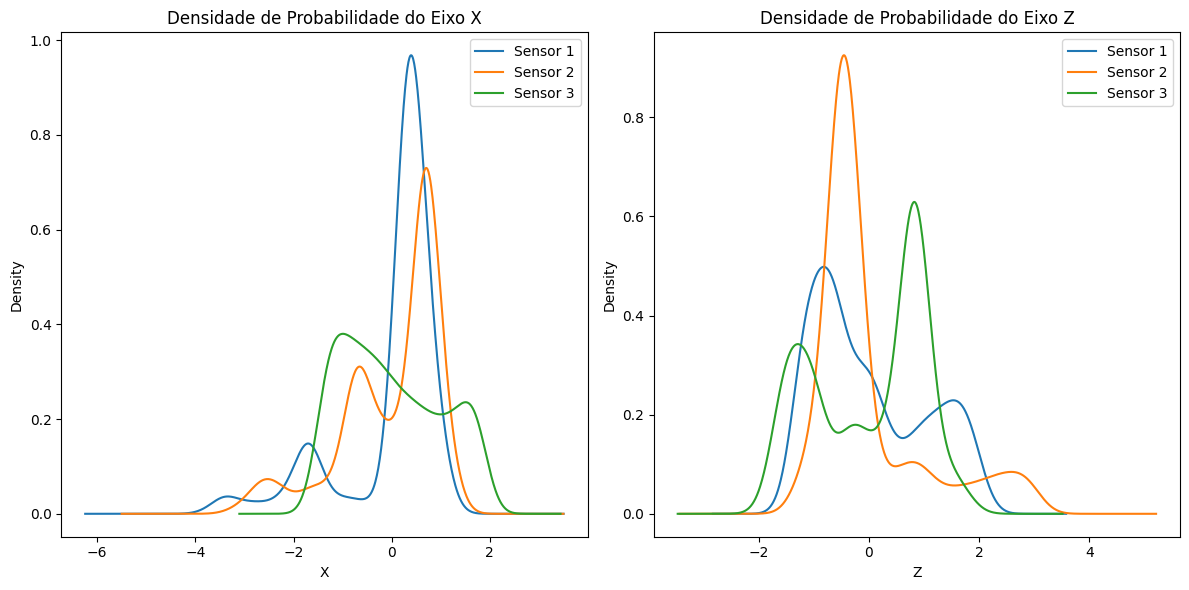

In [25]:
# Considerando que os dados de amostra_sistematica_sensor1, amostra_sistematica_sensor2, e amostra_sistematica_sensor3
# já foram definidos anteriormente

# Criando os DataFrames normalizados e centrados em 0
sensor1 = amostra_sistematica_sensor1 - amostra_sistematica_sensor1.mean()
sensor2 = amostra_sistematica_sensor2 - amostra_sistematica_sensor2.mean()
sensor3 = amostra_sistematica_sensor3 - amostra_sistematica_sensor3.mean()

# Plotando o gráfico de densidade de probabilidade para cada sensor
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Densidade de probabilidade para o eixo X
sensor1['X'].plot(kind='density', ax=axes[0], label='Sensor 1')
sensor2['X'].plot(kind='density', ax=axes[0], label='Sensor 2')
sensor3['X'].plot(kind='density', ax=axes[0], label='Sensor 3')
axes[0].set_title('Densidade de Probabilidade do Eixo X')
axes[0].set_xlabel('X')
axes[0].legend()

# Densidade de probabilidade para o eixo Z
sensor1['Z'].plot(kind='density', ax=axes[1], label='Sensor 1')
sensor2['Z'].plot(kind='density', ax=axes[1], label='Sensor 2')
sensor3['Z'].plot(kind='density', ax=axes[1], label='Sensor 3')
axes[1].set_title('Densidade de Probabilidade do Eixo Z')
axes[1].set_xlabel('Z')
axes[1].legend()

plt.tight_layout()
plt.show()


### Média e Desvio Padrão

In [26]:
# Suponha que 'sensor1', 'sensor2', 'sensor3' sejam DataFrames contendo os dados dos eixos X e Z

# Calculando a média e o desvio padrão para o Sensor 1
media_sensor1_X = amostra_sistematica_sensor1['X'].mean()
desvio_padrao_sensor1_X = amostra_sistematica_sensor1['X'].std()
media_sensor1_Z = amostra_sistematica_sensor1['Z'].mean()
desvio_padrao_sensor1_Z = amostra_sistematica_sensor1['Z'].std()

# Calculando a média e o desvio padrão para o Sensor 2
media_sensor2_X = amostra_sistematica_sensor2['X'].mean()
desvio_padrao_sensor2_X = amostra_sistematica_sensor2['X'].std()
media_sensor2_Z = amostra_sistematica_sensor2['Z'].mean()
desvio_padrao_sensor2_Z = amostra_sistematica_sensor2['Z'].std()

# Calculando a média e o desvio padrão para o Sensor 3
media_sensor3_X = amostra_sistematica_sensor3['X'].mean()
desvio_padrao_sensor3_X = amostra_sistematica_sensor3['X'].std()
media_sensor3_Z = amostra_sistematica_sensor3['Z'].mean()
desvio_padrao_sensor3_Z = amostra_sistematica_sensor3['Z'].std()

# Exibindo as médias e desvios padrões
print("Média e desvio padrão do Sensor 1 - Eixo X:", media_sensor1_X, desvio_padrao_sensor1_X)
print("Média e desvio padrão do Sensor 1 - Eixo Z:", media_sensor1_Z, desvio_padrao_sensor1_Z)
print("Média e desvio padrão do Sensor 2 - Eixo X:", media_sensor2_X, desvio_padrao_sensor2_X)
print("Média e desvio padrão do Sensor 2 - Eixo Z:", media_sensor2_Z, desvio_padrao_sensor2_Z)
print("Média e desvio padrão do Sensor 3 - Eixo X:", media_sensor3_X, desvio_padrao_sensor3_X)
print("Média e desvio padrão do Sensor 3 - Eixo Z:", media_sensor3_Z, desvio_padrao_sensor3_Z)


Média e desvio padrão do Sensor 1 - Eixo X: -0.0028093467679895525 1.00502241268018
Média e desvio padrão do Sensor 1 - Eixo Z: -0.0010165619537262954 0.9995222376055899
Média e desvio padrão do Sensor 2 - Eixo X: -0.002129323261081083 1.0026732084771321
Média e desvio padrão do Sensor 2 - Eixo Z: -0.001297256644543495 0.9981996534373817
Média e desvio padrão do Sensor 3 - Eixo X: 0.0015976153313265514 1.000712165424754
Média e desvio padrão do Sensor 3 - Eixo Z: -0.0012812092185422444 0.9997357375686229


### Plotando o Gráfico

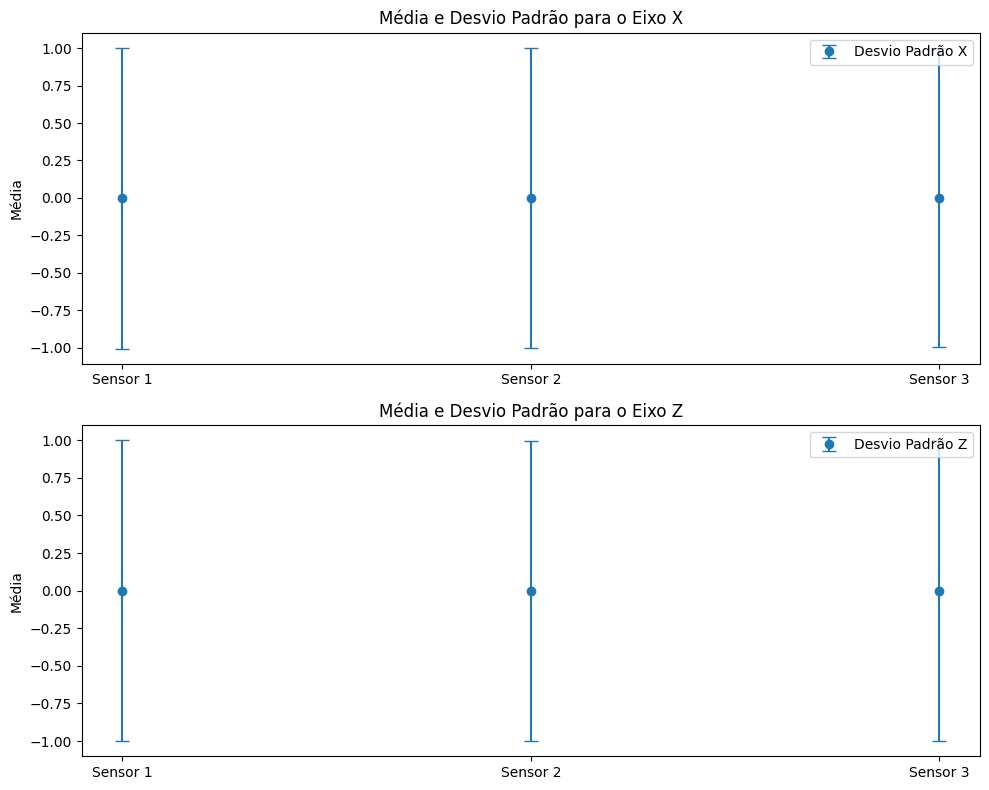

In [27]:
# Criar figura e eixos para o plot
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Dados para plotagem
sensores = ['Sensor 1', 'Sensor 2', 'Sensor 3']
medias_X = [media_sensor1_X, media_sensor2_X, media_sensor3_X]
desvios_X = [desvio_padrao_sensor1_X, desvio_padrao_sensor2_X, desvio_padrao_sensor3_X]
medias_Z = [media_sensor1_Z, media_sensor2_Z, media_sensor3_Z]
desvios_Z = [desvio_padrao_sensor1_Z, desvio_padrao_sensor2_Z, desvio_padrao_sensor3_Z]

# Plot para o eixo X
axs[0].errorbar(sensores, medias_X, yerr=desvios_X, fmt='o', capsize=5, label='Desvio Padrão X')
axs[0].set_title('Média e Desvio Padrão para o Eixo X')
axs[0].set_ylabel('Média')
axs[0].legend()

# Plot para o eixo Z
axs[1].errorbar(sensores, medias_Z, yerr=desvios_Z, fmt='o', capsize=5, label='Desvio Padrão Z')
axs[1].set_title('Média e Desvio Padrão para o Eixo Z')
axs[1].set_ylabel('Média')
axs[1].legend()

# Mostrando o gráfico
plt.tight_layout()
plt.show()

## Magnitude total do Sensor

Para calcular a média e o desvio padrão geral de cada sensor, considerando todos os eixos (X e Z) como um único vetor, primeiro tem-se que calcular a magnitude do vetor para cada ponto de dados e, em seguida, calcular a média e o desvio padrão dessas magnitudes. A magnitude do vetor é uma forma de representar a "força" total do vetor, independentemente da direção, e é calculada usando a raiz quadrada da soma dos quadrados de seus componentes.

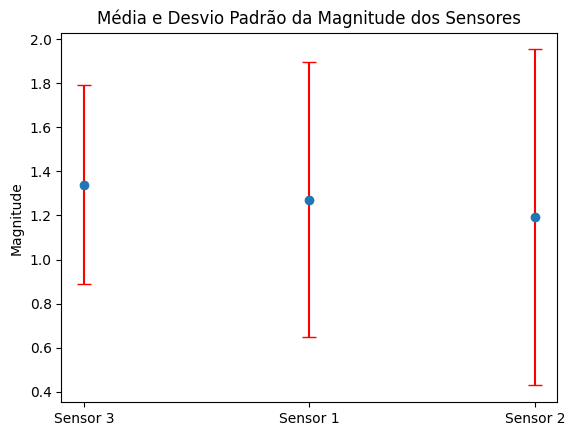

[({'mean': 1.3401950207576887, 'std': 0.45052832177677704}, 'Sensor 3'),
 ({'mean': 1.2723068370482922, 'std': 0.6234819009282256}, 'Sensor 1'),
 ({'mean': 1.190969138487287, 'std': 0.7628425754866069}, 'Sensor 2')]

In [28]:
# Função para calcular a magnitude do vetor
def calcular_magnitude(sensor_data):
    return np.sqrt(sensor_data['X']**2 + sensor_data['Z']**2)

# Calcular a magnitude para cada sensor
magnitude_sensor1 = calcular_magnitude(sensor1)
magnitude_sensor2 = calcular_magnitude(sensor2)
magnitude_sensor3 = calcular_magnitude(sensor3)

# Calcular média e desvio padrão das magnitudes
media_desvio_mag_sensor1 = {'mean': magnitude_sensor1.mean(), 'std': magnitude_sensor1.std()}
media_desvio_mag_sensor2 = {'mean': magnitude_sensor2.mean(), 'std': magnitude_sensor2.std()}
media_desvio_mag_sensor3 = {'mean': magnitude_sensor3.mean(), 'std': magnitude_sensor3.std()}

# Organizando os sensores pela precisão (menor desvio padrão)
sensores_precisao = sorted(
    [(media_desvio_mag_sensor1, 'Sensor 1'), 
     (media_desvio_mag_sensor2, 'Sensor 2'), 
     (media_desvio_mag_sensor3, 'Sensor 3')],
    key=lambda x: x[0]['std']
)

# Extraindo as médias e desvios para a plotagem
sensores = [sensor[1] for sensor in sensores_precisao]
medias = [sensor[0]['mean'] for sensor in sensores_precisao]
desvios = [sensor[0]['std'] for sensor in sensores_precisao]

# Plotando o gráfico de erro
plt.errorbar(sensores, medias, yerr=desvios, fmt='o', ecolor='red', capsize=5)
plt.title('Média e Desvio Padrão da Magnitude dos Sensores')
plt.ylabel('Magnitude')
plt.show()

sensores_precisao  # Retornando os sensores na ordem de precisão (mais preciso primeiro)


#### Ordem de precisão sobre a Magnitude do sensor: 3, 1, 2

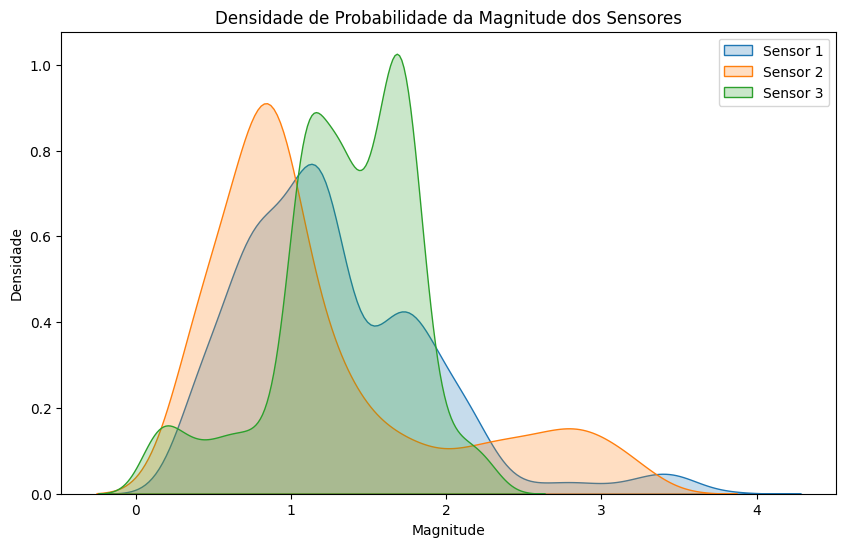

In [29]:
# Plotar a densidade de probabilidade da magnitude para cada sensor
plt.figure(figsize=(10, 6))

sns.kdeplot(magnitude_sensor1, label='Sensor 1', fill=True)
sns.kdeplot(magnitude_sensor2, label='Sensor 2', fill=True)
sns.kdeplot(magnitude_sensor3, label='Sensor 3', fill=True)

plt.title('Densidade de Probabilidade da Magnitude dos Sensores')
plt.xlabel('Magnitude')
plt.ylabel('Densidade')
plt.legend()
plt.show()

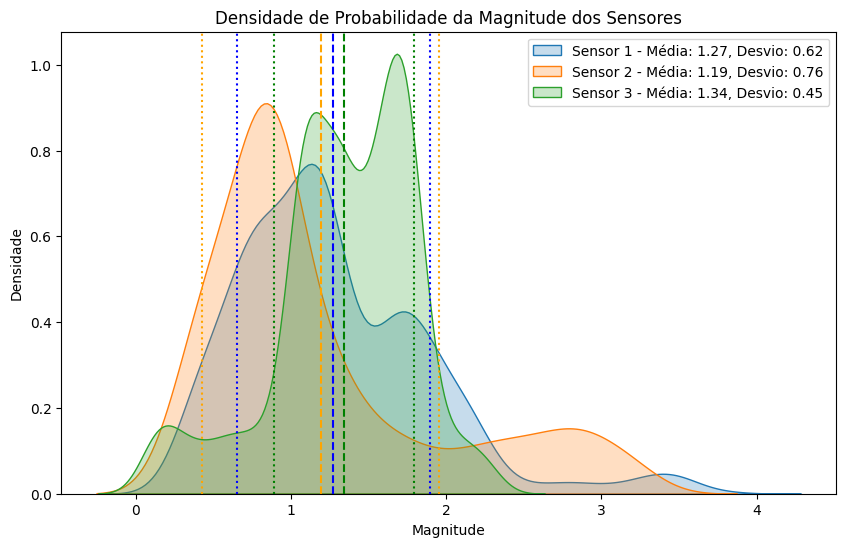

In [30]:
# Plotar a densidade de probabilidade da magnitude para cada sensor
plt.figure(figsize=(10, 6))

sns.kdeplot(magnitude_sensor1, label='Sensor 1 - Média: {:.2f}, Desvio: {:.2f}'.format(magnitude_sensor1.mean(), magnitude_sensor1.std()), fill=True)
plt.axvline(magnitude_sensor1.mean(), color='blue', linestyle='--')
plt.axvline(magnitude_sensor1.mean() + magnitude_sensor1.std(), color='blue', linestyle=':')
plt.axvline(magnitude_sensor1.mean() - magnitude_sensor1.std(), color='blue', linestyle=':')

sns.kdeplot(magnitude_sensor2, label='Sensor 2 - Média: {:.2f}, Desvio: {:.2f}'.format(magnitude_sensor2.mean(), magnitude_sensor2.std()), fill=True)
plt.axvline(magnitude_sensor2.mean(), color='orange', linestyle='--')
plt.axvline(magnitude_sensor2.mean() + magnitude_sensor2.std(), color='orange', linestyle=':')
plt.axvline(magnitude_sensor2.mean() - magnitude_sensor2.std(), color='orange', linestyle=':')

sns.kdeplot(magnitude_sensor3, label='Sensor 3 - Média: {:.2f}, Desvio: {:.2f}'.format(magnitude_sensor3.mean(), magnitude_sensor3.std()), fill=True)
plt.axvline(magnitude_sensor3.mean(), color='green', linestyle='--')
plt.axvline(magnitude_sensor3.mean() + magnitude_sensor3.std(), color='green', linestyle=':')
plt.axvline(magnitude_sensor3.mean() - magnitude_sensor3.std(), color='green', linestyle=':')

plt.title('Densidade de Probabilidade da Magnitude dos Sensores')
plt.xlabel('Magnitude')
plt.ylabel('Densidade')
plt.legend()
plt.show()


### Análise Multivariada

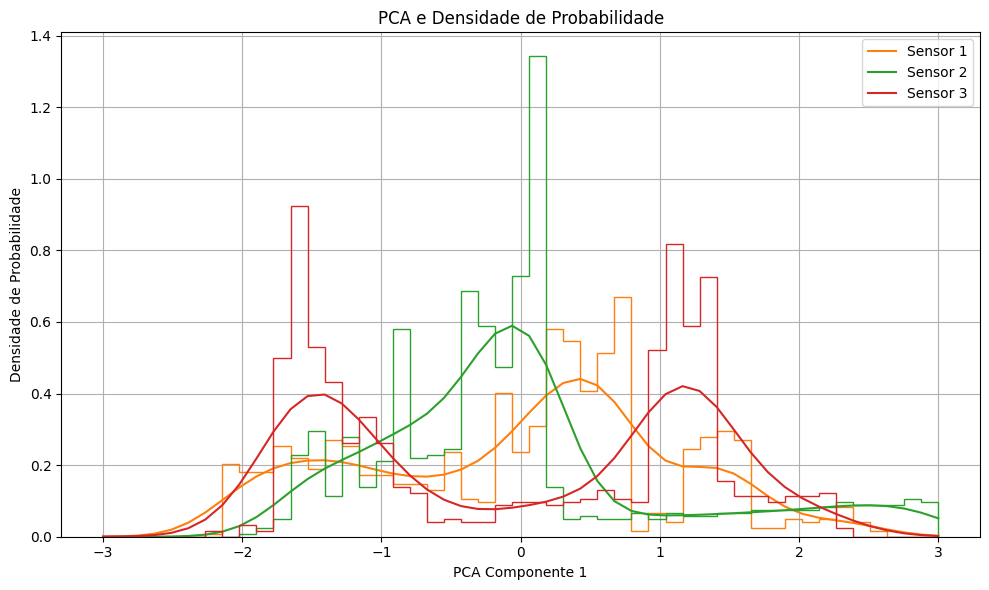

[('Sensor 3', 1.8353726871060467),
 ('Sensor 1', 1.989317550857451),
 ('Sensor 2', 1.9915674837473598)]

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


# Normalizando os dados
scaler = StandardScaler()
sensor1_scaled = scaler.fit_transform(sensor1)
sensor2_scaled = scaler.fit_transform(sensor2)
sensor3_scaled = scaler.fit_transform(sensor3)
sensor1_scaled = sensor1
sensor2_scaled = sensor2
sensor3_scaled = sensor3

# Aplicando PCA
pca = PCA(n_components=2)
sensor1_pca_transformed = pca.fit_transform(sensor1_scaled)
sensor2_pca_transformed = pca.fit_transform(sensor2_scaled)
sensor3_pca_transformed = pca.fit_transform(sensor3_scaled)

plt.figure(figsize=(10,6))

# Plotar PCA 1-D para cada sensor
for i, sensor_pca_transformed in enumerate([sensor1_pca_transformed, sensor2_pca_transformed, sensor3_pca_transformed], 1):
    # PCA 1D - apenas necessário o primeiro eixo
    sensor_pca_1d = sensor_pca_transformed[:, 0]
    # Gerar dados para densidade de probabilidade
    density = stats.gaussian_kde(sensor_pca_1d)
    n, x, _ = plt.hist(sensor_pca_1d, bins=np.linspace(-3, 3, 50), 
                       histtype='step', density=True, color=f'C{i}')  
    plt.plot(x, density(x), color=f'C{i}', label=f'Sensor {i}')
    
plt.legend()
plt.xlabel('PCA Componente 1')
plt.ylabel('Densidade de Probabilidade')
plt.title('PCA e Densidade de Probabilidade')
plt.tight_layout()
plt.grid(True)
plt.show()

# Avaliação qualitativa da precisão dos sensores com base na dispersão dos dados
dispersion = {
    'Sensor 1': np.std(sensor1_pca_transformed, axis=0).sum(),
    'Sensor 2': np.std(sensor2_pca_transformed, axis=0).sum(),
    'Sensor 3': np.std(sensor3_pca_transformed, axis=0).sum()
}

# Ordenando os sensores da maior para a menor precisão com base na dispersão
sorted_sensors = sorted(dispersion.items(), key=lambda x: x[1])
sorted_sensors



#### Análise Multivariada: 3, 1, 2

### Método de estatística multivariada com análise de componentes principais (PCA) para reduzir a dimensionalidade dos dados, e posterior aplicação de técnicas de seleção de amostra de cluster K-Means, para avaliar a consistência dentro de cada grupor de dados

#### Seleção sistemática de amostras

In [32]:
import numpy as np
import pandas as pd

# Suponha que 'data_sensor1', 'data_sensor2', e 'data_sensor3' são os seus DataFrames de dados completos.

def systematic_sampling(df, step):
    """
    Realiza uma amostragem sistemática de um DataFrame.

    Parâmetros:
    df (DataFrame): O DataFrame a ser amostrado.
    step (int): O intervalo de seleção de amostras.

    Retorna:
    DataFrame: O DataFrame amostrado.
    """
    indexes = np.arange(0, len(df), step=step)
    sampled_df = df.iloc[indexes]
    return sampled_df

# Aplicando a amostragem sistemática com um passo definido por você
step_size = 2  # Exemplo de intervalo de amostragem
sampled_sensor1 = systematic_sampling(sensor1, step_size)
sampled_sensor2 = systematic_sampling(sensor2, step_size)
sampled_sensor3 = systematic_sampling(sensor3, step_size)

# Agora você tem DataFrames amostrados que são muito menores e mais gerenciáveis para a análise


In [33]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn import metrics

# Suponha que 'data_sensor1', 'data_sensor2', e 'data_sensor3' são os seus DataFrames de dados completos.

# Reduzindo a dimensionalidade com PCA
pca = PCA(n_components=2)
kmeans = KMeans(n_clusters=4)

sensor1_pca = pca.fit_transform(sensor1)
sensor2_pca = pca.fit_transform(sensor2)
sensor3_pca = pca.fit_transform(sensor3)

# Aplicando KMeans
sensor1_clusters = kmeans.fit(sensor1_pca)
sensor2_clusters = kmeans.fit(sensor2_pca)
sensor3_clusters = kmeans.fit(sensor3_pca)

# Avaliando a qualidade do cluster com o silhouette score
sensor1_score = metrics.silhouette_score(sensor1_pca, sensor1_clusters.labels_)
sensor2_score = metrics.silhouette_score(sensor2_pca, sensor2_clusters.labels_)
sensor3_score = metrics.silhouette_score(sensor3_pca, sensor3_clusters.labels_)

# Organizando os sensores do pior para o melhor com base no silhouette score
sensor_scores = [('Sensor 1', sensor1_score), ('Sensor 2', sensor2_score), ('Sensor 3', sensor3_score)]
sensor_scores.sort(key=lambda x: x[1])  # Ordena do menor para o maior score
sensor_scores  # Do pior (menor score) para o melhor (maior score)


C:\Users\nhf75\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\nhf75\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\nhf75\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set

[('Sensor 2', 0.04226934324813306),
 ('Sensor 1', 0.31034000711786336),
 ('Sensor 3', 0.5515283327364393)]

[('Sensor 1', 0.34813993836477936),
 ('Sensor 2', 0.4047300339558977),
 ('Sensor 3', 0.6622251529873968)]

 
Análise anterior de correlação: 3, 2, 1.

Análise anterior de PCA: 3, 1, 2.

Análise anterior de magnitude: 3, 1, 2.

Análise anterior por eixo: 2, 3, 1.

#### Plot Gráfico

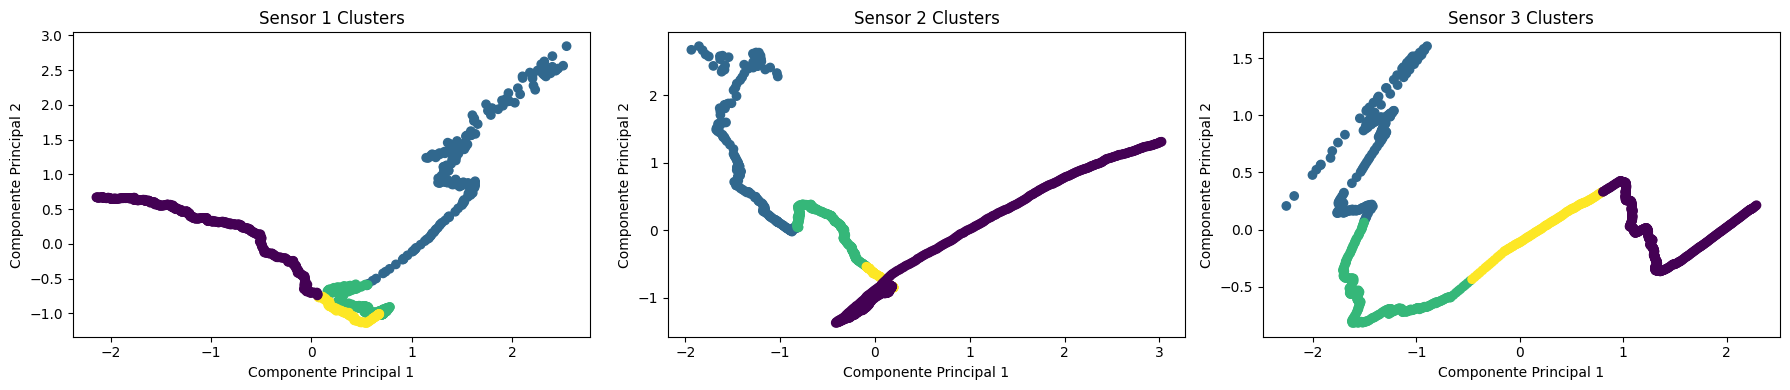

In [34]:
import matplotlib.pyplot as plt

# Criando os plots dos clusters para cada sensor
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot para o Sensor 1
axes[0].scatter(sensor1_pca[:, 0], sensor1_pca[:, 1], c=sensor1_clusters.labels_, cmap='viridis', marker='o')
axes[0].set_title('Sensor 1 Clusters')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')

# Plot para o Sensor 2
axes[1].scatter(sensor2_pca[:, 0], sensor2_pca[:, 1], c=sensor2_clusters.labels_, cmap='viridis', marker='o')
axes[1].set_title('Sensor 2 Clusters')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')

# Plot para o Sensor 3
axes[2].scatter(sensor3_pca[:, 0], sensor3_pca[:, 1], c=sensor3_clusters.labels_, cmap='viridis', marker='o')
axes[2].set_title('Sensor 3 Clusters')
axes[2].set_xlabel('Componente Principal 1')
axes[2].set_ylabel('Componente Principal 2')

plt.tight_layout()
plt.show()
